In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
train = pd.read_csv("../data/raw/train.csv")

In [3]:
df = pd.DataFrame({
    "hours": [1,2,3,4,5,6],
    "score": [50,55,65,70,75,85]
})

In [4]:
X = df["hours"]
y = df["score"]

X = sm.add_constant(X)   # adds intercept

model = sm.OLS(y, X)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.984
Method:                 Least Squares   F-statistic:                     314.2
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           5.95e-05
Time:                        19:50:25   Log-Likelihood:                -10.186
No. Observations:                   6   AIC:                             24.37
Df Residuals:                       4   BIC:                             23.95
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         42.6667      1.507     28.320      0.0

/home/gabrielborges/dev/predict_customer_churn/.venv/lib/python3.11/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [5]:
model = smf.ols("score ~ hours", data=df)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.984
Method:                 Least Squares   F-statistic:                     314.2
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           5.95e-05
Time:                        19:50:58   Log-Likelihood:                -10.186
No. Observations:                   6   AIC:                             24.37
Df Residuals:                       4   BIC:                             23.95
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     42.6667      1.507     28.320      0.0

/home/gabrielborges/dev/predict_customer_churn/.venv/lib/python3.11/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [6]:
pred = results.predict(df)

df["predicted_score"] = predpred = results.predict(df)

df["predicted_score"] = pred

In [7]:
new = pd.DataFrame({"hours":[7,8,9]})
results.predict(new)

0     90.666667
1     97.523810
2    104.380952
dtype: float64

In [8]:
df = pd.DataFrame({
    "hours":[1,2,3,4,5],
    "sleep":[7,6,6,5,5],
    "score":[50,55,63,70,72]
})

In [9]:
model = smf.ols("score ~ hours + sleep", data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.975
Model:                            OLS   Adj. R-squared:                  0.949
Method:                 Least Squares   F-statistic:                     38.49
Date:                Thu, 12 Mar 2026   Prob (F-statistic):             0.0253
Time:                        19:52:23   Log-Likelihood:                -8.5826
No. Observations:                   5   AIC:                             23.17
Df Residuals:                       2   BIC:                             21.99
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     56.4667     28.465      1.984      0.1

/home/gabrielborges/dev/predict_customer_churn/.venv/lib/python3.11/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [10]:
model = smf.ols("score ~ hours * sleep", data=df).fit()

In [11]:
df["hours2"] = df["hours"]**2

model = smf.ols("score ~ hours + hours2", data=df).fit()

In [12]:
model = smf.ols("score ~ hours + I(hours**2)", data=df).fit()

In [13]:
df = pd.DataFrame({
    "method":["A","A","B","B","C"],
    "score":[60,62,70,72,68]
})

In [14]:
model = smf.ols("score ~ C(method)", data=df).fit()

In [15]:
df = pd.DataFrame({
    "hours":[1,2,3,4,5,6],
    "passed":[0,0,0,1,1,1]
})

In [16]:
model = smf.logit("passed ~ hours", data=df).fit()
print(model.summary())

         Current function value: 0.000000
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                 passed   No. Observations:                    6
Model:                          Logit   Df Residuals:                        4
Method:                           MLE   Df Model:                            1
Date:                Thu, 12 Mar 2026   Pseudo R-squ.:                   1.000
Time:                        19:54:32   Log-Likelihood:            -1.5713e-10
converged:                      False   LL-Null:                       -4.1589
Covariance Type:            nonrobust   LLR p-value:                  0.003926
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -162.7984   5.58e+05     -0.000      1.000   -1.09e+06    1.09e+06
hours         46.5518   1.61e+05      0.000      1.000   -3.15e+0

/home/gabrielborges/dev/predict_customer_churn/.venv/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/gabrielborges/dev/predict_customer_churn/.venv/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/gabrielborges/dev/predict_customer_churn/.venv/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/gabrielborges/dev/predict_customer_churn/.venv/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning:

In [17]:
model.predict(df)

0    3.271396e-51
1    5.394089e-31
2    8.894122e-11
3    1.000000e+00
4    1.000000e+00
5    1.000000e+00
dtype: float64

In [18]:
(model.predict(df) > 0.5).astype(int)

0    0
1    0
2    0
3    1
4    1
5    1
dtype: int64

In [19]:
residuals = results.residresiduals = results.resid

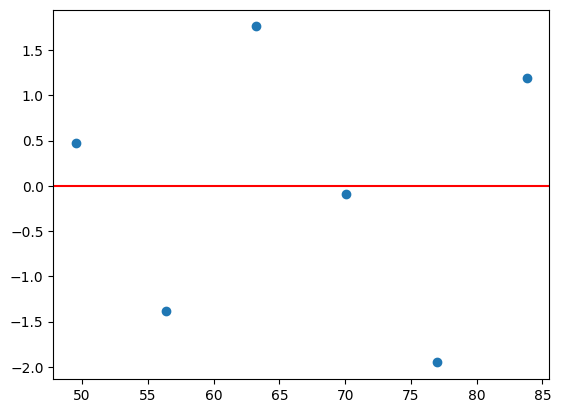

In [20]:
import matplotlib.pyplot as plt

plt.scatter(results.fittedvalues, residuals)
plt.axhline(0, color="red")
plt.show()

In [21]:
from scipy import stats

stats.shapiro(residuals)

ShapiroResult(statistic=0.9534369352055159, pvalue=0.7679998176148661)

In [22]:
from statsmodels.stats.diagnostic import het_breuschpagan

het_breuschpagan(residuals, results.model.exog)

(0.544212608711856,
 0.46069210926875126,
 0.39899839908047735,
 0.5619064368402913)

In [23]:
results.get_robustcov_results(cov_type="HC3")

In [24]:
from statsmodels.stats.anova import anova_lm

anova_lm(results)

,df,sum_sq,mean_sq,F,PR(>F)
hours,1.0,822.857143,822.857143,314.181818,0.00006
Residual,4.0,10.476190,2.619048,NaN,NaN


In [26]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df["passed"], order=(1,1,1))
results = model.fit()

print(results.summary())

                               SARIMAX Results                                
Dep. Variable:                 passed   No. Observations:                    6
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -3287.998
Date:                Thu, 12 Mar 2026   AIC                           6581.997
Time:                        19:56:48   BIC                           6580.825
Sample:                             0   HQIC                          6578.852
                                  - 6                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1       4.308e-07   1.19e-17   3.61e+10      0.000    4.31e-07    4.31e-07
ma.L1       4.308e-07   1.19e-17   3.61e+10      0.000    4.31e-07    4.31e-07
sigma2         0.0002   4.58e-08   3304.895      0.0

/home/gabrielborges/dev/predict_customer_churn/.venv/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1431: RuntimeWarning: divide by zero encountered in divide
  test_statistic = numer_squared_sum / denom_squared_sum


In [27]:
results.forecast(steps=5)

6     1.0
7     1.0
8     1.0
9     1.0
10    1.0
Name: predicted_mean, dtype: float64

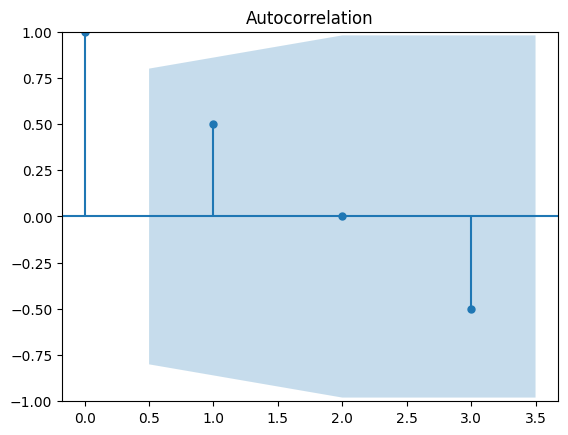

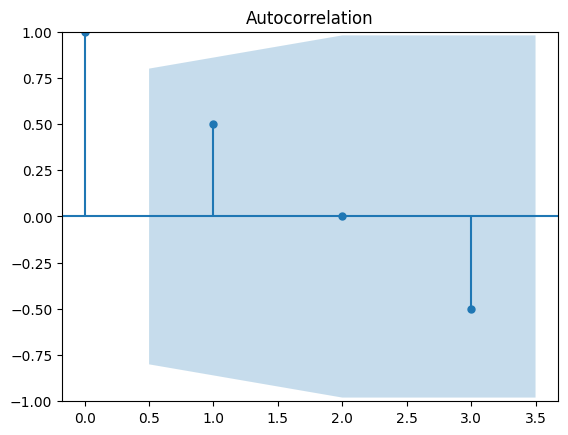

In [29]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df["passed"])

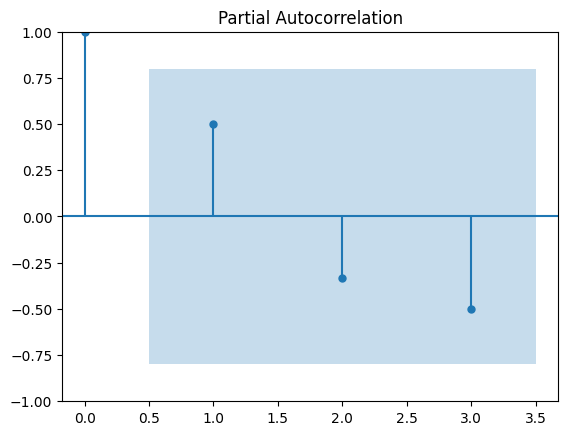

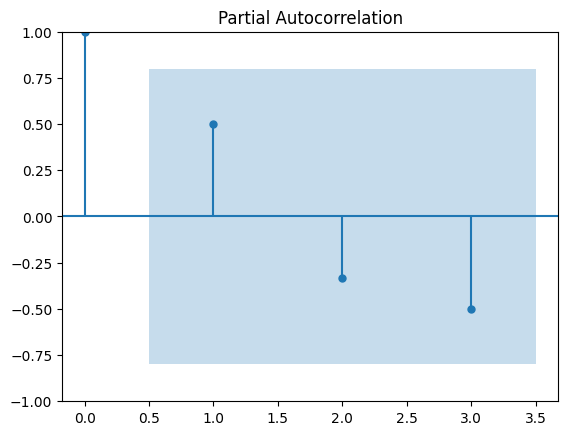

In [30]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(df["passed"])

In [32]:
model = smf.glm(
    formula="passed ~ hours",
    data=df,
    family=sm.families.Poisson()
).fit()

print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 passed   No. Observations:                    6
Model:                            GLM   Df Residuals:                        4
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3.8066
Date:                Thu, 12 Mar 2026   Deviance:                       1.6131
Time:                        19:59:00   Pearson chi2:                     1.46
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3458
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.4167      2.369     -1.442      0.1

In [34]:
results.params
results.pvalues
results.conf_int()
results.fittedvalues
results.resid

0    0.000000e+00
1    0.000000e+00
2    0.000000e+00
3    1.000000e+00
4   -8.616324e-07
5    3.711476e-13
dtype: float64